# Auto MPG – Feature Engineering and Linear Regression
## 1. Introduction

The main objective of this project is to perform feature engineering and build linear regression models to predict a car's fuel efficiency (mpg) based on its technical specifications. The independent variables are selected using two approaches:

* Forward Selection (custom implementation)
* Backward Selection (custom implementation)

The performance of the resulting models will then be compared, followed by an analysis and interpretation of the obtained results.


## 2. Brief Description of the Dataset
The analysis uses the Auto MPG dataset from the UCI Machine Learning Repository. The dataset contains information about cars and their fuel efficiency. It consists of 398 observations and 7 explanatory variables, with mpg as the target variable.

The dataset includes the following car characteristics:

* mpg – fuel efficiency measured in miles per gallon; this is the dependent variable in the regression models
* cylinders – number of engine cylinders
* displacement – engine displacement
* horsepower – engine horsepower
* weight – vehicle weight
* acceleration – acceleration performance
* model_year – year of manufacture
* origin – origin of the car


## 3. Libraries

In [98]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.colormaps()
cmap = plt.get_cmap("Pastel1")

from scipy.stats import norm
from scipy.stats import f_oneway
from scipy.stats import boxcox
from scipy.stats import shapiro

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.tools.tools import add_constant

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [95]:
!pip install git+https://github.com/kingagla/tukey_with_groups

  Cloning https://github.com/kingagla/tukey_with_groups to c:\users\user\appdata\local\temp\pip-req-build-y10ogtvx
  Resolved https://github.com/kingagla/tukey_with_groups to commit f1c429af8089329f646f0d003115ccdee0237251
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
    Preparing wheel metadata: started
    Preparing wheel metadata: finished with status 'done'


  Running command git clone -q https://github.com/kingagla/tukey_with_groups 'C:\Users\User\AppData\Local\Temp\pip-req-build-y10ogtvx'


## 4. Data upload

In [99]:
columns = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year",
    "origin", "car_name"
]

df = pd.read_csv("auto-mpg.data",sep=r"\s+",names=columns,na_values="?")

In [100]:
with open("auto-mpg.names", "r") as file:
    print(file.read())

1. Title: Auto-Mpg Data

2. Sources:
   (a) Origin:  This dataset was taken from the StatLib library which is
                maintained at Carnegie Mellon University. The dataset was 
                used in the 1983 American Statistical Association Exposition.
   (c) Date: July 7, 1993

3. Past Usage:
    -  See 2b (above)
    -  Quinlan,R. (1993). Combining Instance-Based and Model-Based Learning.
       In Proceedings on the Tenth International Conference of Machine 
       Learning, 236-243, University of Massachusetts, Amherst. Morgan
       Kaufmann.

4. Relevant Information:

   This dataset is a slightly modified version of the dataset provided in
   the StatLib library.  In line with the use by Ross Quinlan (1993) in
   predicting the attribute "mpg", 8 of the original instances were removed 
   because they had unknown values for the "mpg" attribute.  The original 
   dataset is available in the file "auto-mpg.data-original".

   "The data concerns city-cycle fuel consumptio

## 5. Descriptive statistics

In [101]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [102]:
#statistical summary of numerical columns in seasons_stats - numerical variables

df_desc_numerical = df.describe()
df_desc_numerical = df_desc_numerical.drop(columns = ['origin'], inplace = False)
df_desc_numerical.loc['skewness'] = round(df_desc_numerical.skew(numeric_only = True), 2)
df_desc_numerical.loc['kurtosis'] = round(df_desc_numerical.kurt(numeric_only = True), 2)
df_desc_numerical

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000
skewness,2.780000,2.830000,0.850000,1.710000,0.410000,2.820000,2.550000
kurtosis,8.720000,8.990000,-0.470000,2.770000,-0.350000,8.920000,7.280000


In [103]:
#statistical summary of categorical columns in seasons_stats - categorical variables

df_desc_categorical = df[['car_name', 'origin']].copy()
df_desc_categorical['origin'] = df_desc_categorical['origin'].astype('category')
df_desc_categorical = df_desc_categorical.describe()
df_desc_categorical

,car_name,origin
count,398,398
unique,305,3
top,ford pinto,1
freq,6,249


### origin - categorical variables

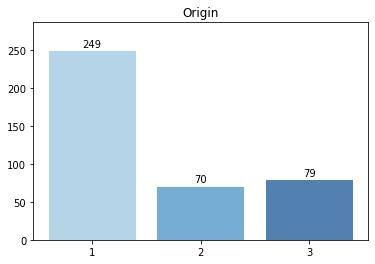

In [104]:
origin_bar = df['origin'].value_counts().sort_index()
origin_bar

colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(origin_bar)))

bars = plt.bar(origin_bar.index, origin_bar.values, color = colors_bar, alpha = 0.7)

plt.xticks(origin_bar.index)
plt.ylim(0, max(origin_bar.values) * 1.15)
plt.bar_label(bars, fontsize = 10, padding = 2)
plt.title("Origin");

### car_name - categorical variables

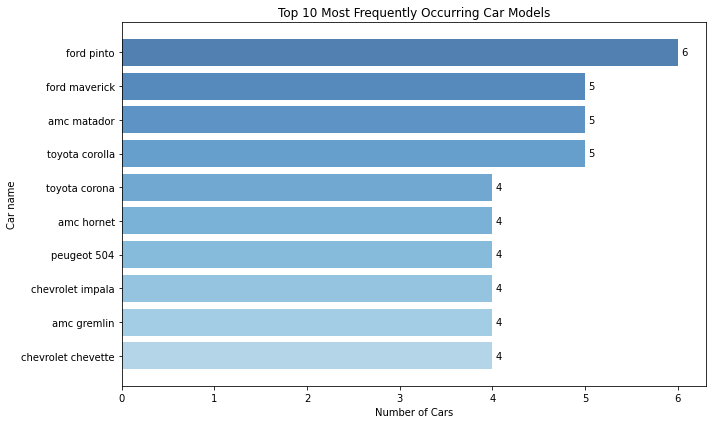

In [105]:
car_name_bar = df['car_name'].value_counts().head(10).sort_values()

plt.figure(figsize=(10,6))
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(car_name_bar)))

bars = plt.barh(car_name_bar.index, car_name_bar.values, color = colors_bar, alpha = 0.7)

plt.bar_label(bars, fontsize = 10, padding = 3)
plt.xlabel('Number of Cars')
plt.ylabel('Car name')
plt.title('Top 10 Most Frequently Occurring Car Models')

plt.tight_layout()
plt.show()

### Comment:
The dataset contains 398 observations and 8 variables, including the target variable mpg. Most variables are numerical, while origin and car_name are categorical variables. origin represents the origin of the car, while car_name represents the car model name.


In [106]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [107]:
df[df["horsepower"].isna() == True]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
32,25.0,4,98.0,NaN,2046.0,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875.0,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835.0,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905.0,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320.0,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035.0,20.5,82,1,amc concord dl


### Comment:

There are 6 missing values for the horsepower variable.

## 6. Relationship Between Variables

In [108]:
df_corr = df.drop(columns = ['origin'])
numeric_df = df_corr.select_dtypes(include="number")
numeric_df.corr()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000


In [109]:
# ANOVA
# H0: The mean mpg is the same across all cylinder groups.
# H1: At least one group has a different mean mpg.

groups = [
    group["mpg"].values
    for _, group in df.groupby("cylinders")
]

stat, p_value = f_oneway(*groups)
alpha = 0.05

print("F-statistic:", stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Reject H0 - the mean mpg differs between groups.")
else:
    print("Fail to reject H0 - there is insufficient evidence of differences between groups.")

F-statistic: 172.5917853028911
p-value: 3.679939295400561e-85
Reject H0 - the mean mpg differs between groups.


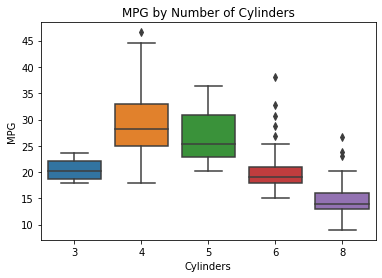

In [110]:
sns.boxplot(data=df, x="cylinders", y="mpg")
plt.title("MPG by Number of Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("MPG")
plt.show()

In [111]:
tukey = pairwise_tukeyhsd(endog=df["mpg"],groups=df["cylinders"],alpha=0.05)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     3      4   8.7368 0.0027   2.1903  15.2832   True
     3      5   6.8167 0.3264  -3.0866  16.7199  False
     3      6  -0.5643 0.9993     -7.2   6.0715  False
     3      8  -5.5869 0.1416 -12.1948    1.021  False
     4      5  -1.9201 0.9569  -9.4611   5.6209  False
     4      6  -9.3011    0.0  -10.982  -7.6201   True
     4      8 -14.3237    0.0  -15.891 -12.7564   True
     5      6   -7.381 0.0627 -14.9996   0.2377  False
     5      8 -12.4036 0.0001 -19.9979  -4.8092   True
     6      8  -5.0226    0.0  -6.9289  -3.1164   True
------------------------------------------------------


### Comment:

The Tukey HSD test revealed statistically significant differences in mean MPG between the 3–4, 4–6, 4–8, 5–8, and 6–8 cylinder groups. No statistically significant differences were found between the remaining pairs. The largest difference occurs between the 4- and 8-cylinder groups, with a mean MPG difference of approximately 14.32.

In [112]:
df["origin"].value_counts()

1    249
3     79
2     70
Name: origin, dtype: int64

In [113]:
groups = [
    group["mpg"].values
    for _, group in df.groupby("origin")
]

f_stat, p_value = f_oneway(*groups)
alpha = 0.05

print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Reject H0 - there are statistically significant differences between the groups.")
else:
    print("Fail to reject H0 - there is insufficient evidence of differences between the groups.")

F-statistic: 98.54179491075871
p-value: 1.9154864184128e-35
Reject H0 - there are statistically significant differences between the groups.


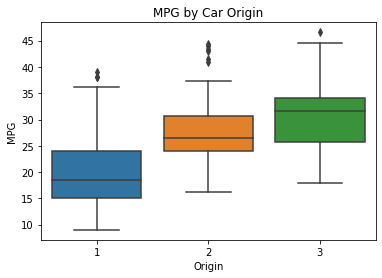

In [114]:
sns.boxplot(data=df, x="origin", y="mpg")
plt.title("MPG by Car Origin")
plt.xlabel("Origin")
plt.ylabel("MPG")
plt.show()


In [115]:
tukey = pairwise_tukeyhsd(endog=df["mpg"], groups=df["origin"], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     1      2   7.8079    0.0  5.771  9.8448   True
     1      3  10.3671    0.0 8.4228 12.3114   True
     2      3   2.5592 0.0404 0.0877  5.0307   True
---------------------------------------------------


### Comment: 

There are statistically significant differences in mean fuel efficiency (mpg) between cars from different origin groups. The Tukey HSD test revealed significant differences in mean mpg between all origin groups. The largest difference occurs between groups 1 and 3, amounting to approximately 10.37 MPG.

## 7. Correlation Analysis of the Original Data

              cylinders  displacement  horsepower    weight  acceleration  \
cylinders      1.000000      0.950721    0.842983  0.896017     -0.505419   
displacement   0.950721      1.000000    0.897257  0.932824     -0.543684   
horsepower     0.842983      0.897257    1.000000  0.864538     -0.689196   
weight         0.896017      0.932824    0.864538  1.000000     -0.417457   
acceleration  -0.505419     -0.543684   -0.689196 -0.417457      1.000000   
model_year    -0.348746     -0.370164   -0.416361 -0.306564      0.288137   

              model_year  
cylinders      -0.348746  
displacement   -0.370164  
horsepower     -0.416361  
weight         -0.306564  
acceleration    0.288137  
model_year      1.000000  


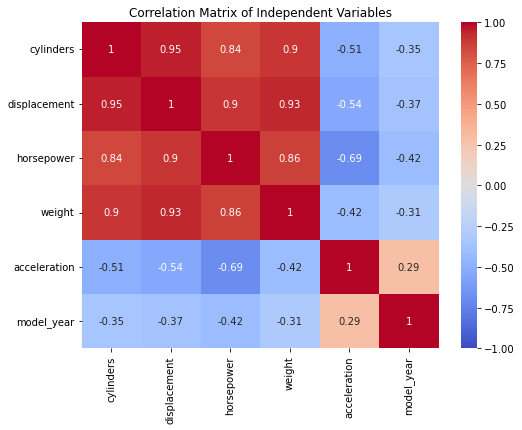

In [116]:
X = df[[
    "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year"
]]

corr = X.corr()

print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Independent Variables")
plt.show()

## 8. Feature engineering

###  a. Handling Missing Data

In [117]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [118]:
df[df["horsepower"].isna() == True]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
32,25.0,4,98.0,NaN,2046.0,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875.0,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835.0,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905.0,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320.0,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035.0,20.5,82,1,amc concord dl


In [119]:
(df.isna().mean()*100).round(2)

mpg             0.00
cylinders       0.00
displacement    0.00
horsepower      1.51
weight          0.00
acceleration    0.00
model_year      0.00
origin          0.00
car_name        0.00
dtype: float64

In [120]:
df[df["horsepower"].isna() == True]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
32,25.0,4,98.0,NaN,2046.0,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875.0,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835.0,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905.0,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320.0,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035.0,20.5,82,1,amc concord dl


In [121]:
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].mean())

In [122]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

###  b. Data Encoding

In [123]:
df = pd.get_dummies(df, columns = ['origin'], drop_first = True)

### Comment:
The origin variable was encoded using One-Hot Encoding because it contains the values 1, 2, and 3. Treating these values as numerical variables could incorrectly imply an ordinal relationship, such as 1 < 2 < 3.

### c. Creating New Variables

In [124]:
df["hp_per_cylinder"] = df["horsepower"] / df["cylinders"]
df["weight_per_displacement"] = df["weight"] / df["displacement"]

df  = df.drop(columns = ['horsepower','cylinders','weight','displacement'])

In [125]:
df.columns

Index(['mpg', 'acceleration', 'model_year', 'car_name', 'origin_2', 'origin_3',
       'hp_per_cylinder', 'weight_per_displacement'],
      dtype='object')

In [126]:
features = [
    "acceleration","model_year","hp_per_cylinder","weight_per_displacement"]

X = df[features]
y = df["mpg"]

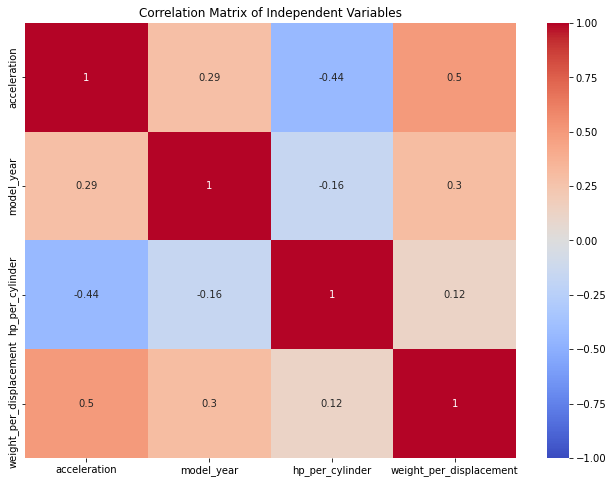

In [127]:
corr = X.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Independent Variables")
plt.show()

### d. Data Transformation

In [128]:
df.columns

Index(['mpg', 'acceleration', 'model_year', 'car_name', 'origin_2', 'origin_3',
       'hp_per_cylinder', 'weight_per_displacement'],
      dtype='object')

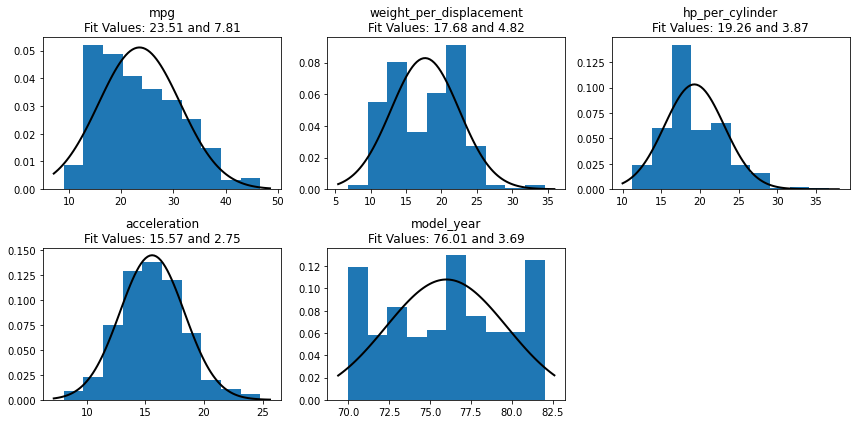

In [129]:
columns = [
    "mpg",
    "weight_per_displacement",
    "hp_per_cylinder",
    "acceleration",
    "model_year"
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, column in zip(axes.flatten(), columns):

    transformed = df[column].dropna()

    mu, std = norm.fit(transformed)

    ax.hist(transformed, density=True)

    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)

    ax.plot(x, p, 'k', linewidth=2)

    ax.set_title(
        "{}\nFit Values: {:.2f} and {:.2f}".format(
            column, mu, std
        )
    )


fig.delaxes(axes.flatten()[-1])

plt.tight_layout()
plt.show()

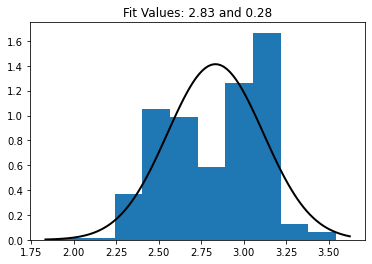

In [130]:
df["log_weight_per_displacement"] = np.log(df["weight_per_displacement"])
transformed_dis = df["log_weight_per_displacement"]
                              

mu, std = norm.fit(transformed_dis)

plt.hist(transformed_dis, density=True)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'k', linewidth=2)

title = "Fit Values: {:.2f} and {:.2f}".format(mu, std)
plt.title(title)

plt.show()

In [131]:
shapiro(transformed_dis)

ShapiroResult(statistic=0.9507643717911146, pvalue=2.9997040298171166e-10)

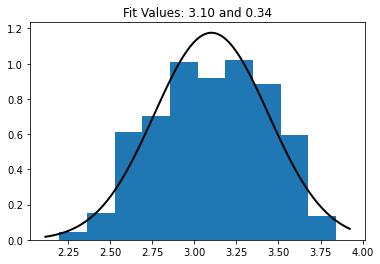

In [132]:
df["log_mpg"] = np.log(df["mpg"])
transformed_mpg = df["log_mpg"]
                              

mu, std = norm.fit(transformed_mpg)

plt.hist(transformed_mpg, density=True)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'k', linewidth=2)

title = "Fit Values: {:.2f} and {:.2f}".format(mu, std)
plt.title(title)

plt.show()

In [133]:
shapiro(transformed_mpg)

ShapiroResult(statistic=0.9823355680056024, pvalue=8.774470234782868e-05)

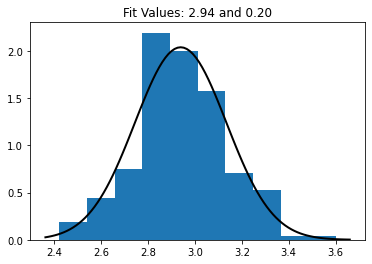

In [134]:
df["log_hp_per_cylinder"] = np.log(df["hp_per_cylinder"])
transformed_hors = df["log_hp_per_cylinder"]
                              

mu, std = norm.fit(transformed_hors)

plt.hist(transformed_hors, density=True)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'k', linewidth=2)

title = "Fit Values: {:.2f} and {:.2f}".format(mu, std)
plt.title(title)

plt.show()

In [135]:
shapiro(transformed_hors)

ShapiroResult(statistic=0.991602225618266, pvalue=0.0236841570704722)

### Comment:

The histograms after transformation are relatively close to the shape of a normal distribution; however, some deviations from normality are still visible.

At the significance level of α = 0.05, the p-value obtained from the Shapiro–Wilk test is substantially lower than the significance level. Therefore, we reject the null hypothesis of normality. This indicates that, despite their visually similar shape to a normal distribution, the transformed variables are not normally distributed in the statistical sense.

The transformation improved the visual shape of the distributions but did not result in the normality assumption being satisfied according to the Shapiro–Wilk test.


In [136]:
corr

,acceleration,model_year,hp_per_cylinder,weight_per_displacement
acceleration,1.000000,0.288137,-0.436235,0.496180
model_year,0.288137,1.000000,-0.158954,0.304517
hp_per_cylinder,-0.436235,-0.158954,1.000000,0.122418
weight_per_displacement,0.496180,0.304517,0.122418,1.000000


### Comment:

Two additional variables were created:

hp_per_cylinder – the ratio of engine horsepower to the number of cylinders,
weight_per_displacement – the ratio of vehicle weight to engine displacement.

Based on the correlation matrix, the strongest relationship can be observed between acceleration and weight_per_displacement, with a correlation coefficient of 0.496. This indicates a moderate positive relationship, meaning that as the value of weight_per_displacement increases, there is a tendency for acceleration to increase as well.

In contrast, hp_per_cylinder and weight_per_displacement show a very weak positive correlation of 0.122, indicating a negligible linear relationship between the variables. A moderate negative correlation can also be observed between acceleration and hp_per_cylinder (−0.436).

In the next stage, the impact of individual variables on the quality of the linear regression model will be evaluated, and an additional multicollinearity analysis will be performed using the Variance Inflation Factor (VIF).

### Preliminary Multicollinearity Analysis Using VIF

In [137]:
df_new = df.drop(columns=["mpg", "car_name",'hp_per_cylinder','weight_per_displacement'])
df_new.columns

Index(['acceleration', 'model_year', 'origin_2', 'origin_3',
       'log_weight_per_displacement', 'log_mpg', 'log_hp_per_cylinder'],
      dtype='object')

In [138]:
Xvar = df.drop(columns=["mpg", "car_name",'hp_per_cylinder','weight_per_displacement'])

Xvif = add_constant(Xvar.astype(float))

vif = pd.DataFrame({
    "features": Xvar.columns,
    "VIF Factor": [
        variance_inflation_factor(Xvif.values, i)
        for i in range(1, Xvif.shape[1])
    ]
})

vif

,features,VIF Factor
0,acceleration,2.390577
1,model_year,1.654375
2,origin_2,1.871171
3,origin_3,1.924773
4,log_weight_per_displacement,5.227704
5,log_mpg,3.776361
6,log_hp_per_cylinder,1.864718


### Comment:

The VIF values indicate that most variables do not exhibit a multicollinearity problem. The highest VIF value is observed for log_weight_per_displacement (5.23), which may indicate a moderate level of multicollinearity. The remaining variables have VIF values below 4, suggesting that they do not represent a significant multicollinearity concern.

### e. Feature Selection - Forward_selection


In [139]:
df_new.columns

Index(['acceleration', 'model_year', 'origin_2', 'origin_3',
       'log_weight_per_displacement', 'log_mpg', 'log_hp_per_cylinder'],
      dtype='object')

In [140]:
def forward_selection(df_new, y_name='log_mpg', tolerance=0.01):
    attr_names = list(df_new.drop([y_name], axis=1).columns)
    all_possible = attr_names.copy()

    model = LinearRegression()

    current_names = []
    last_score = 0
    cur_diff = 1

    while current_names != all_possible and cur_diff > tolerance:
        scores = []

        for name in attr_names:
            columns = current_names + [name]

            model.fit(df_new[columns], df_new[y_name])
            score = model.score(df_new[columns], df_new[y_name])

            scores.append((name, score))

        best = np.argmax([score for _, score in scores])
        chosen_col, best_score = scores[best]

        current_names.append(chosen_col)
        cur_diff = best_score - last_score

        attr_names.remove(chosen_col)
        last_score = best_score

        print(scores)
        print("Chosen columns:", chosen_col, best_score)
        print("Current features:", current_names)
        print()

    return current_names

In [141]:
selected_features = forward_selection(df_new)

print(selected_features)

[('acceleration', 0.19874562352683278), ('model_year', 0.3321704019899713), ('origin_2', 0.07358035022533493), ('origin_3', 0.18592741149059355), ('log_weight_per_displacement', 0.5613355227823227), ('log_hp_per_cylinder', 0.04139479221888387)]
Chosen columns: log_weight_per_displacement 0.5613355227823227
Current features: ['log_weight_per_displacement']

[('acceleration', 0.564219341306449), ('model_year', 0.6790472427388987), ('origin_2', 0.5652583862639751), ('origin_3', 0.5729845577293213), ('log_hp_per_cylinder', 0.6221090977175026)]
Chosen columns: model_year 0.6790472427388987
Current features: ['log_weight_per_displacement', 'model_year']

[('acceleration', 0.6791031345974106), ('origin_2', 0.6791023027079619), ('origin_3', 0.6873158589744841), ('log_hp_per_cylinder', 0.7135098536924571)]
Chosen columns: log_hp_per_cylinder 0.7135098536924571
Current features: ['log_weight_per_displacement', 'model_year', 'log_hp_per_cylinder']

[('acceleration', 0.7284283692706144), ('origin_

### Feature Scaling

In [142]:
model_forward = LinearRegression()

X_forward = df_new[selected_features]
y = df["log_mpg"]

In [143]:
scaler = StandardScaler()
X_forward_scaled = scaler.fit_transform(X_forward)

In [144]:
model_forward.fit(X_forward_scaled, y)
r2_forward = model_forward.score(X_forward_scaled, y)
y_pred_forward = model_forward.predict(X_forward_scaled)

print("R^2:", r2_forward)

R^2: 0.7336228284028179


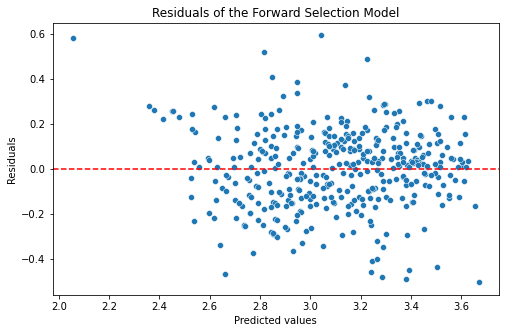

In [145]:
residuals = y - y_pred_forward

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_forward, y=residuals)

plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals of the Forward Selection Model")
plt.show()

### Comment:

As a result of applying the Forward Selection method, the following variables were selected for the model: acceleration, model_year, origin_3, log_weight_per_displacement, and log_hp_per_cylinder. Based on the selected variables, a linear regression model was built to predict the logarithm of mpg (log_mpg). The model achieved an R² coefficient of 0.734, which means that approximately 73.4% of the variability in log_mpg is explained by the model.

In the residual plot, most observations are located around zero and do not form any clear pattern. The spread of the residuals is relatively large, especially for lower predicted values; however, there is no clear funnel-shaped pattern. There are also a few observations with larger residual values, which may be potential outliers. Overall, the residuals are distributed fairly randomly, indicating that the model does not show any clear violation of the assumption of constant residual variance.

### f. Feature Selection - Backward_selection 

In [146]:
def backward_selection(df_new, y_name='log_mpg', tolerance=0.01):
    attr_names = list(df_new.drop([y_name], axis=1).columns)

    model = LinearRegression()

    current_names = attr_names.copy()

    model.fit(df_new[current_names], df_new[y_name])
    last_score = model.score(df_new[current_names], df_new[y_name])

    cur_diff = 1

    while len(current_names) > 1 and cur_diff > tolerance:
        scores = []

        for name in current_names:
            columns = current_names.copy()
            columns.remove(name)

            model.fit(df_new[columns], df_new[y_name])
            score = model.score(df_new[columns], df_new[y_name])

            scores.append((name, score))

        best = np.argmax([score for _, score in scores])
        removed_col, best_score = scores[best]

        cur_diff = last_score - best_score

        if cur_diff > tolerance:
            break

        current_names.remove(removed_col)
        last_score = best_score

        print(scores)
        print("Removed column:", removed_col, best_score)
        print("Current features:", current_names)
        print("R2 difference:", cur_diff)
        print()

    return current_names

In [147]:
selected_features_backward = backward_selection(df_new)

model_backward = LinearRegression()

X_backward = df_new[selected_features_backward]
y = df_new["log_mpg"]

model_backward.fit(X_backward, y)

r2_backward = model_backward.score(X_backward, y)
y_pred_backward = model_backward.predict(X_backward)

print("Wybrane cechy:", selected_features_backward)
print("R^2:", r2_backward)

[('acceleration', 0.7260224384633984), ('model_year', 0.6435618535364294), ('origin_2', 0.7336228284028179), ('origin_3', 0.7284723249317279), ('log_weight_per_displacement', 0.6165058449329485), ('log_hp_per_cylinder', 0.6926981724766976)]
Removed column: origin_2 0.7336228284028179
Current features: ['acceleration', 'model_year', 'origin_3', 'log_weight_per_displacement', 'log_hp_per_cylinder']
R2 difference: 0.0015719805680147747

Wybrane cechy: ['acceleration', 'model_year', 'origin_3', 'log_weight_per_displacement', 'log_hp_per_cylinder']
R^2: 0.7336228284028179


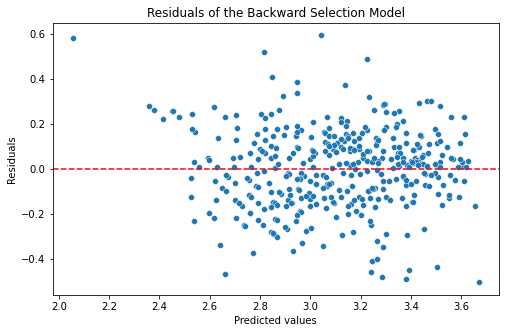

In [148]:
residuals = y - y_pred_backward

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_backward, y=residuals)

plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals of the Backward Selection Model")
plt.show()

### Comment:

As a result of applying the Backward Selection method, the following variables were selected for the model: acceleration, model_year, origin_3, log_weight_per_displacement, and log_hp_per_cylinder. Based on these variables, a linear regression model was built to predict the logarithm of mpg (log_mpg). The model achieved an R² coefficient of 0.733, which means that approximately 73.3% of the variability in mpg values is explained by the model.

In the residual plot, most observations are located around zero and do not form any clear pattern. The spread of the residuals is relatively large, especially for lower predicted values; however, there is no clear funnel-shaped pattern. There are also a few observations with larger residual values, which may be potential outliers. Overall, the distribution of the residuals can be considered fairly random, so the assumption of constant residual variance appears to be satisfied to a greater extent than suggested by the previous plot.

## 9. Comparison of the Two Models

In [149]:
y_original = df['mpg']

y_pred_forward_original = np.exp(y_pred_forward)
y_pred_backward_original = np.exp(y_pred_backward)

r2_forward = r2_score(y_original, y_pred_forward_original)
rmse_forward = np.sqrt(mean_squared_error(y_original,y_pred_forward_original ))
mae_forward = mean_absolute_error(y_original, y_pred_forward_original)

r2_backward = r2_score(y_original, y_pred_backward_original)
rmse_backward = np.sqrt(mean_squared_error(y_original, y_pred_backward_original))
mae_backward = mean_absolute_error(y_original, y_pred_backward_original)

results = pd.DataFrame({
    "Model": ["Forward", "Backward"],
    "R2": [r2_forward, r2_backward],
    "RMSE": [rmse_forward, rmse_backward],
    "MAE": [mae_forward, mae_backward]
})

print(results)

      Model        R2      RMSE       MAE
0   Forward  0.730788  4.050273  3.071155
1  Backward  0.730788  4.050273  3.071155


## 10. Summary

As part of the project, an analysis of car-related data was conducted, and linear regression models were developed to predict mpg values. During the analysis, additional variables were created, including the ratio of engine power to the number of cylinders and the ratio of car weight to engine displacement.

In the first notebook, a linear regression model was built without applying standardization or logarithmic transformation. Then, in the second stage of the analysis, the data were appropriately transformed and standardized, after which variable selection and model development were performed again.

A comparison of the two approaches showed an improvement in model performance after applying the transformations and standardization. The R² coefficient increased from 0.704 to 0.731, while RMSE decreased from 4.25 to 4.05 and MAE from 3.23 to 3.07. This indicates that the model based on appropriately preprocessed data explains the variability in mpg values better and has a lower prediction error.

Ultimately, the model with logarithmic transformation and standardization was considered to be better, as it achieved a higher R² value and lower RMSE and MAE values. The analysis demonstrated that appropriate data preprocessing and variable selection can have a significant impact on the quality of a regression model.